In [3]:
# Initialize Otter
import otter
grader = otter.Notebook("intro2Seaborn.ipynb")

## Lecture Section

In this lecture, we will cover the `seaborn` library. `seaborn` is a statistical plotting library that is built on-top of matplotlib. It creates beautiful plots with minimal effort.

We will cover:
* Customizing Plots
    * Scaling
    * Themes
    * Color Palettes
* Seaborn Specific Plots
    * Violinplot
    * Swarmplot
    * Histplot
    * Distplot
    * Jointplot
    * Pairplot

This lecture-assignment is completely graded by-hand, there is no autograder. To maintain consistency, it used the same technology as the autograded lecture-assignments. comman

We will use the `iris` dataset because it is clean and easily accessible.

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

data = sns.load_dataset("iris")
data


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### Customization

There are five themes we can use when plotting with seaborn. They are `white`, `dark`, `whitegrid`, `darkgrid`, and `ticks`. Try a couple below.

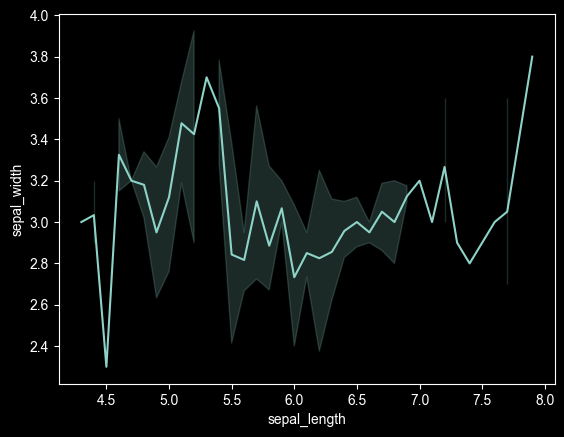

In [5]:
sns.lineplot(x="sepal_length", y="sepal_width", data=data)
sns.set_style("whitegrid")
plt.show()

We can easily scale our figure using `set_context()`- and options like `paper`, `talk`, and `poster`.

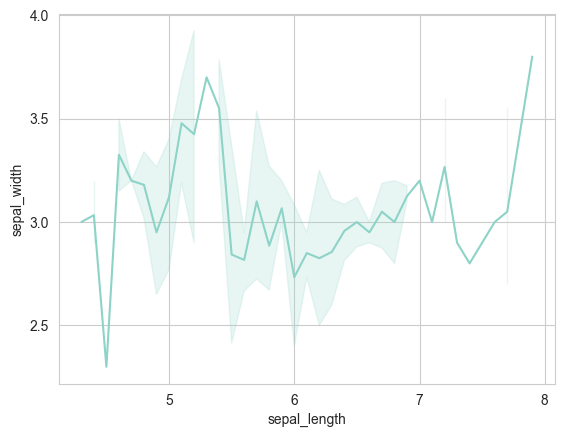

In [6]:
sns.lineplot(x="sepal_length", y="sepal_width", data=data)
sns.set_context("poster")

plt.show()

Color palettes are one of the most important features of seaborn.

To check the current color palette we are using, we call `sns.palette()`

In [7]:
sns.color_palette()


[(0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
 (0.996078431372549, 1.0, 0.7019607843137254),
 (0.7490196078431373, 0.7333333333333333, 0.8509803921568627),
 (0.9803921568627451, 0.5058823529411764, 0.4549019607843137),
 (0.5058823529411764, 0.6941176470588235, 0.8235294117647058),
 (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
 (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
 (0.7372549019607844, 0.5098039215686274, 0.7411764705882353),
 (0.8, 0.9215686274509803, 0.7686274509803922),
 (1.0, 0.9294117647058824, 0.43529411764705883)]

The color palette above is a **qualitative** color palette. It works well with categorical data.

The palette below is a **diverging** color palette. It has colors that can be easily told apart on each end, and a nuetral color in the middle.

In [8]:
sns.color_palette('PiYG', 11)


[(0.7344867358708189, 0.08788927335640138, 0.4604382929642445),
 (0.8359861591695502, 0.33933102652825836, 0.6145328719723183),
 (0.9085736255286428, 0.5926182237600922, 0.770319108035371),
 (0.9607843137254902, 0.7686274509803921, 0.8823529411764706),
 (0.9884659746251442, 0.8925797770088427, 0.9421760861207228),
 (0.9673202614379085, 0.968473663975394, 0.9656286043829296),
 (0.9124183006535949, 0.9620146097654748, 0.8396770472895041),
 (0.781699346405229, 0.9084967320261439, 0.6222222222222226),
 (0.6032295271049597, 0.8055363321799309, 0.3822376009227222),
 (0.42883506343713956, 0.679123414071511, 0.21061130334486736),
 (0.2756632064590542, 0.540715109573241, 0.12387543252595157)]

The last type of color palette is **sequential**. This type of palette focuses on one color and brightens from left to right.

In [9]:
sns.color_palette('Greens', 11)


[(0.9221222606689735, 0.9701499423298732, 0.9065282583621684),
 (0.8606689734717416, 0.9458362168396771, 0.8385697808535179),
 (0.7792233756247597, 0.9132333717800846, 0.7518031526336024),
 (0.681045751633987, 0.8718954248366013, 0.6562091503267974),
 (0.5739331026528259, 0.8241753171856978, 0.5606151480199923),
 (0.45176470588235296, 0.7670895809304115, 0.4612072279892349),
 (0.31999999999999995, 0.7024990388312188, 0.3966166858900423),
 (0.21568627450980393, 0.6287581699346405, 0.3333333333333333),
 (0.1340253748558247, 0.5423298731257208, 0.26828143021914647),
 (0.04359861591695502, 0.4648212226066897, 0.20369088811995384),
 (0.0, 0.37259515570934254, 0.14980392156862746)]

There are a lot of built-in palettes. View them here:
https://seaborn.pydata.org/tutorial/color_palettes.html#sequential-color-palettes
or
https://www.practicalpythonfordatascience.com/ap_seaborn_palette

For all palettes, the `_r` version is a continuous color gradiant, while the name without `_r` is a discrete version.

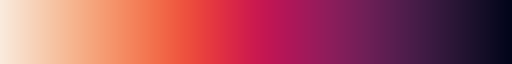

In [10]:
sns.color_palette("rocket_r", as_cmap=True)

If we wish to change the default color palette, we use `set_palette()`

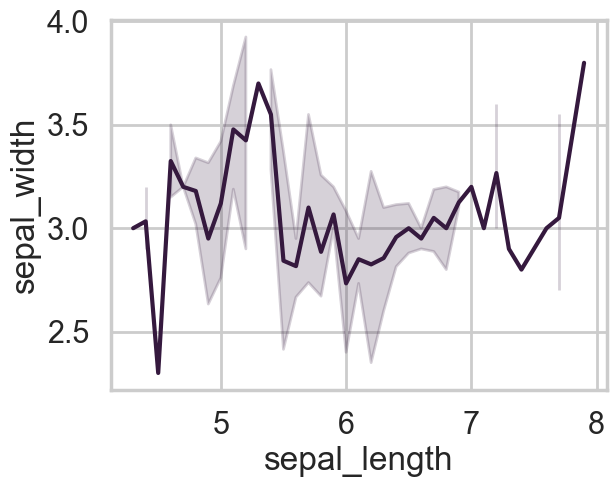

In [11]:
data = sns.load_dataset("iris")
sns.set_palette('rocket')
sns.lineplot(x="sepal_length", y="sepal_width", data=data)


### Seaborn Specific Plots

We will briefly talk about a few unique plots. These plots may not be exclusive to `seaborn` but they do look nicer. To save time, we won't cover the simpler plots that we did with `matplotlib` because they work nearly the same. Don't forget that they exist, though!

**Violinplot** : similar to a boxplot, but uses the kernel density estimation to graph the shape. Thick sections show a higher distribution of points, and thinner sections show a lower distribution of points. THe white, centered dot is the median, and the thicker line protruding from it is the interquartile range. Finally, the thin line in the middle is 1.5x interquartile range. Points outside of this range are outliers.

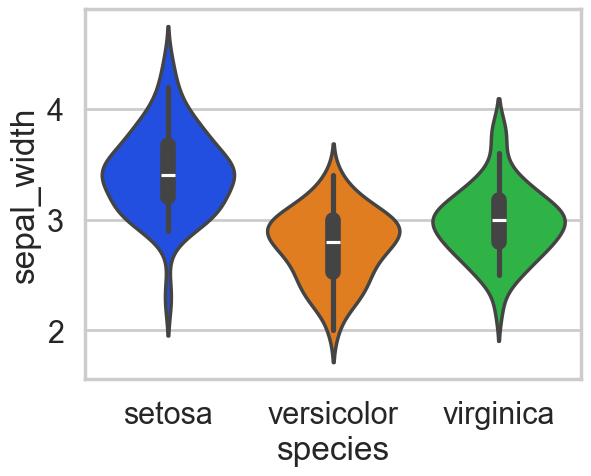

In [12]:
data = sns.load_dataset("iris")
sns.set_palette('bright')
sns.violinplot(x='species', y='sepal_width', data=data, hue = 'species') # hue colors based on category

**Swarmplot** : similar to violinplot, but with less information and dots. It can be considered a scatterplot for categories.

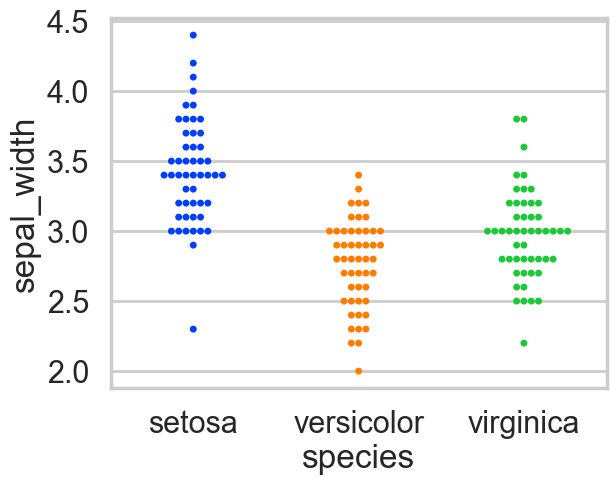

In [13]:
data = sns.load_dataset("iris")
sns.set_palette('bright')
sns.swarmplot(x='species', y='sepal_width', data=data, hue = 'species') # hue colors based on category

Some people like them together...

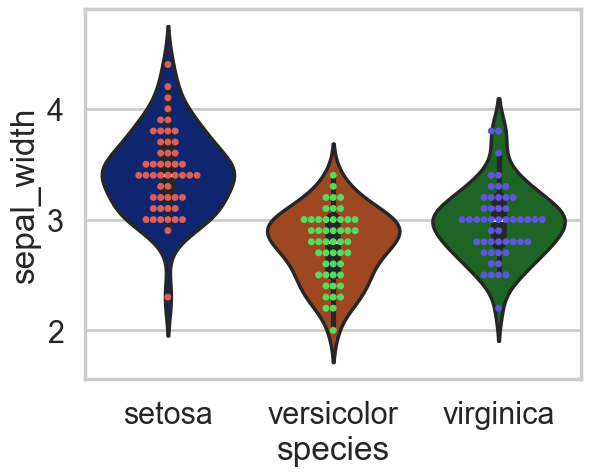

In [14]:
data = sns.load_dataset("iris")
sns.set_palette('dark')
sns.violinplot(x='species', y='sepal_width', data=data, hue = 'species') # hue colors based on category
sns.set_palette('hls', 3)
sns.swarmplot(x='species', y='sepal_width', data=data, hue = 'species') # hue colors based on category

**Histplot** : a histplot is a histogram-like plot for categorical data. Each column shows the distribution of data for that specific category.

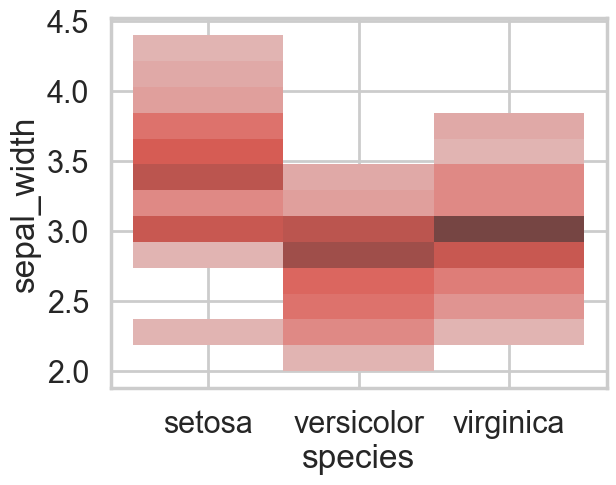

In [15]:
data = sns.load_dataset("iris")
sns.histplot(x='species', y='sepal_width', data=data)

We can give `histplot()` one column for a normal histogram with counts, and we can graph the `kde` if we choose.

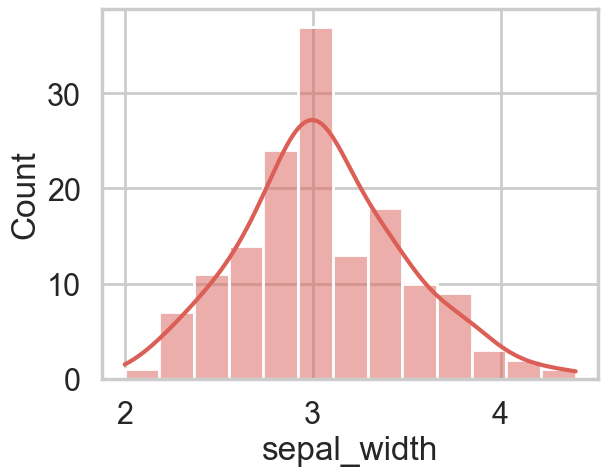

In [16]:
sns.histplot(data["sepal_width"], kde=True)


One step further, we can turn the counts into a density.

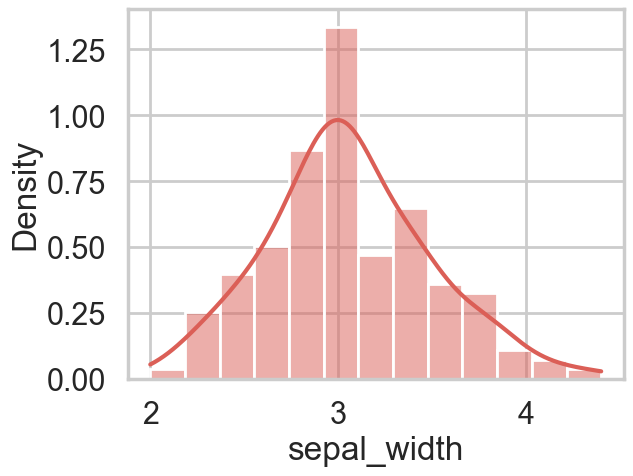

In [17]:
sns.histplot(data["sepal_width"], kde=True, stat='density')

**Jointplot** : a jointplot plots two variables with univariate and bivariate graphs

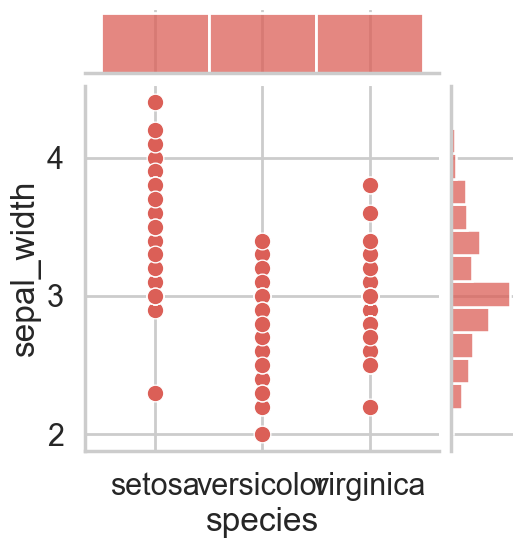

In [18]:
data = sns.load_dataset("iris")
sns.jointplot(x='species', y='sepal_width', data=data)

**Pairplot** : a pairplot graphs a pairwise relationship. It creates a plot between each numerical column. The diagonal has the density plot for each variable. All other plots are scatterplots between the two variables. Note that this is a little different that the usual `ggpairs()` method in R: we do not have a correlation coefficient in the upper triangle here.

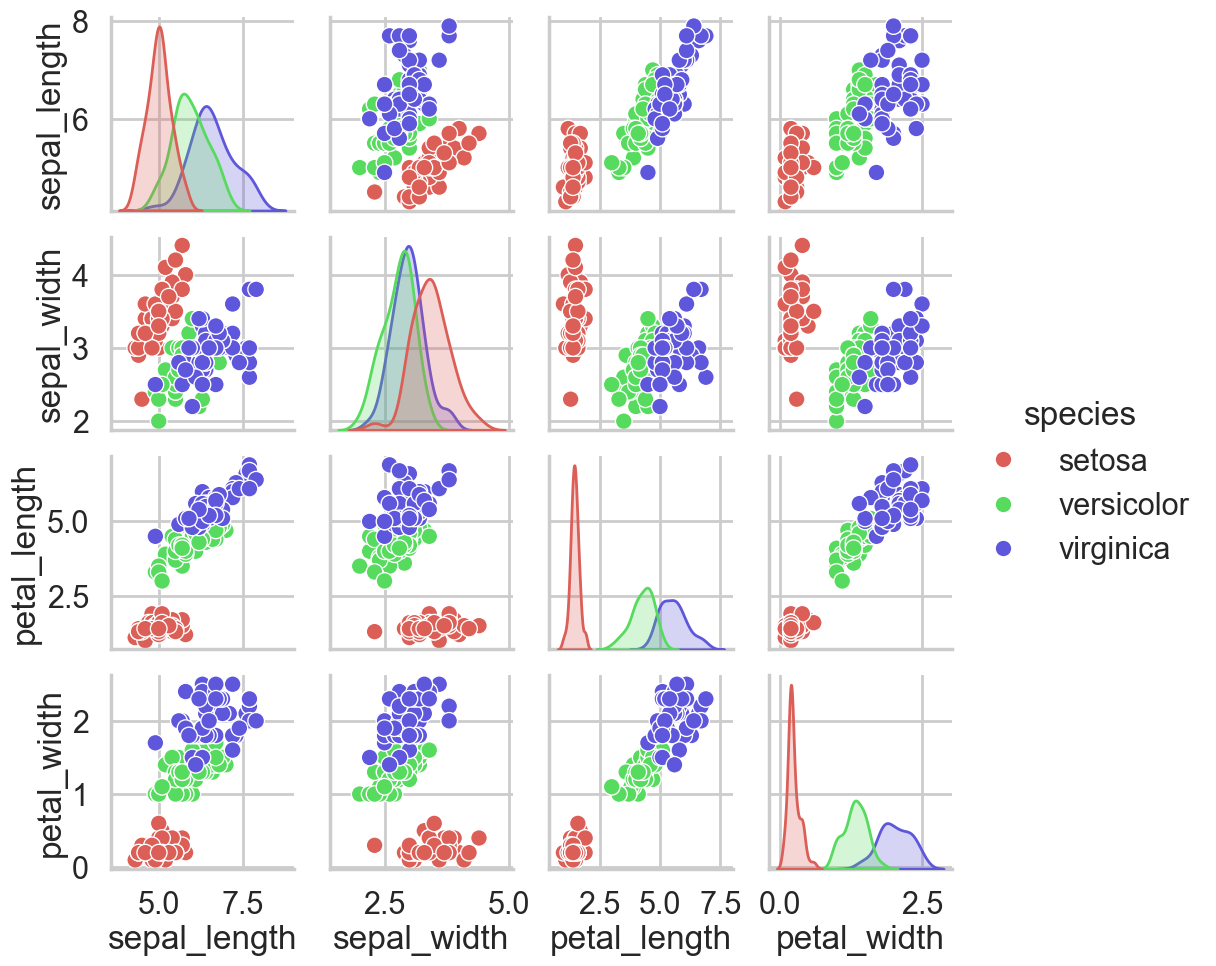

In [19]:
data = sns.load_dataset("iris")
sns.pairplot(data=data, hue='species')

Pairplots can be very computationally expensive. I recommend saving the figure as an image, then displaying that image instead of re-running the code (unless your code has changed).

## Assignment Section

Some of the questions will be manually graded, and some will be autograded.


<!-- BEGIN QUESTION -->

**Question 1.**

Use the 'tips' dataset from seaborn. It is loaded in for you.

Create a histogram of the total_bill variable.
Make sure the plot has an appropriate title and axis labels. Do not forget to show the plot!

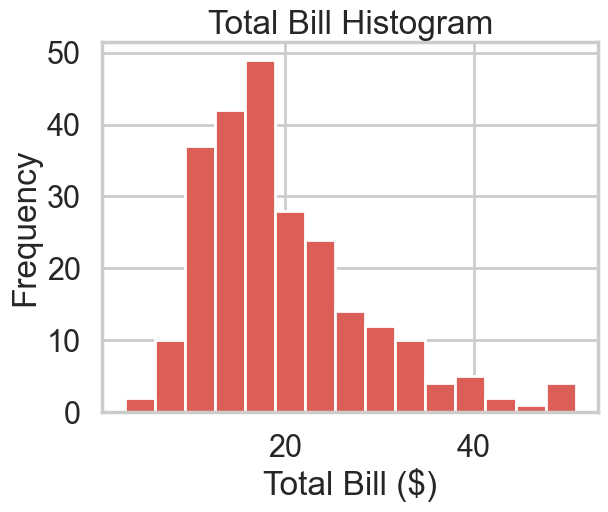

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
tips = sns.load_dataset("tips")

# Creating the histogram
plt.hist(tips["total_bill"], bins=15)

# Adding labels and title and displaying the histogram
plt.title("Total Bill Histogram", fontsize=12)
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.**

Create a scatterplot of total_bill vs. tip.
Then add a linear regression line to the plot. Color points by sex.

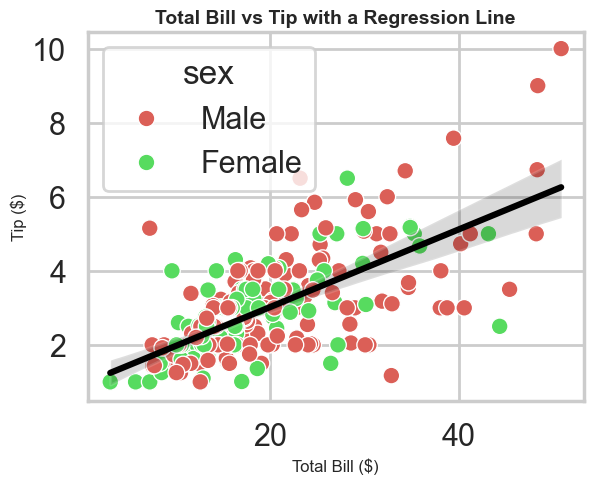

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
tips = sns.load_dataset("tips")

# Creating scatterplot colored by sex
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")

# Adding the linear regression line to the scatterplot
sns.regplot(data=tips, x="total_bill", y="tip", scatter=False, color="black")

# Adding labels and title and displaying the scatterplot
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)
plt.title("Total Bill vs Tip with a Regression Line", fontsize=14, fontweight='bold')
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 3.**

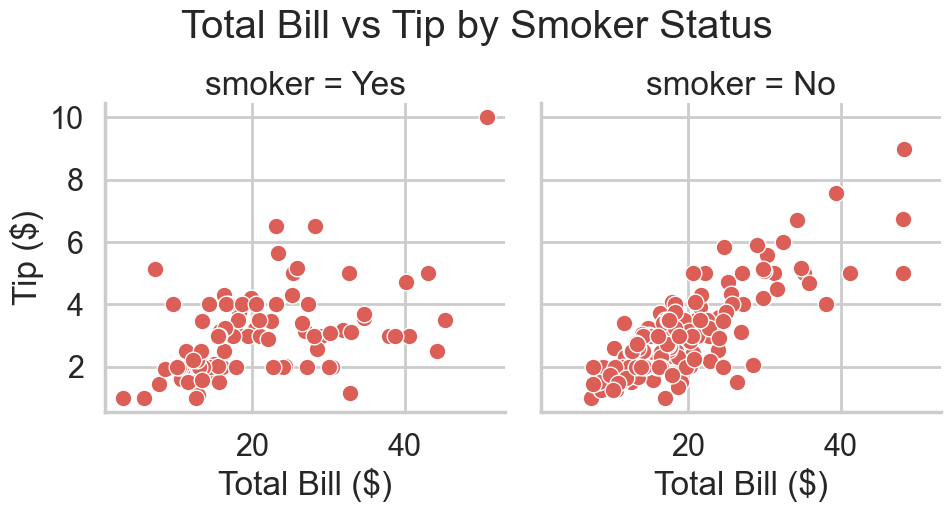

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
tips = sns.load_dataset("tips")

# Creating the relational plot that compares smoker vs non-smoker
g = sns.relplot(data=tips, x="total_bill", y="tip", col="smoker")

# Adding labels and title and displaying the relational plot
g.set_axis_labels("Total Bill ($)", "Tip ($)")
plt.suptitle("Total Bill vs Tip by Smoker Status", y=1.05)
plt.show()

<!-- END QUESTION -->

**Question 4.**

Please ignore me :) - I am a free point!

In [20]:
x = 1

In [ ]:
grader.check("q4")

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [39]:
grader.check_all()

q4 results: All test cases passed!